In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

maj_tick_width = 0.8
min_tick_width = 0.8

plot_params = { "figure.dpi": "200", "axes.labelsize": 14, "axes.linewidth": 1.5, "axes.titlesize": 20, "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.title_fontsize": 11, "legend.fontsize": 11, "xtick.major.size": 3.5, "xtick.major.width": maj_tick_width, "xtick.minor.size": 2.5, "xtick.minor.width": min_tick_width, "ytick.major.size": 3.5, "ytick.major.width": maj_tick_width, "ytick.minor.size": 2.5, "ytick.minor.width": min_tick_width, "font.family": "serif", "text.usetex": True, "xtick.direction": "in","ytick.direction": "in", "pgf.texsystem": "pdflatex","font.family": "serif", "text.usetex": True, "pgf.rcfonts": False,}

plt.rcParams.update(plot_params)

done


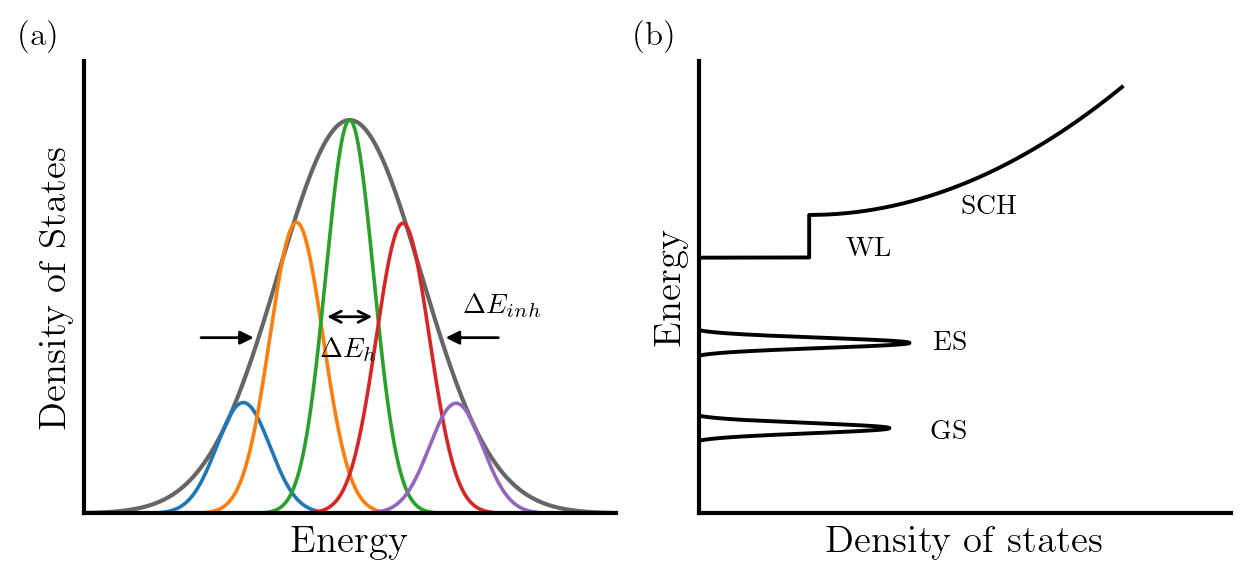

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def gauss(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.3, 3))

# ============================================================
# Panel (a): Ensemble Density of States - inhomogeneous broadening
# ============================================================
x = np.linspace(0, 10, 2000)

env = gauss(x, 5.0, 1.35, 2.35)
ax1.plot(x, env, color='0.4', linewidth=1.5)

peaks = [
    dict(mu=3.0, sigma=0.50, amp=env[570]),
    dict(mu=4.0, sigma=0.50, amp=env[790]),
    dict(mu=5.0, sigma=0.45, amp=env[1000]),
    dict(mu=6.0, sigma=0.50, amp=env[1210]),
    dict(mu=7.0, sigma=0.50, amp=env[1430]),
]

for p in peaks:
    y = gauss(x, p['mu'], p['sigma'], p['amp'])
    ax1.plot(x, y, linewidth=1.3)

# broad grey envelope (inhomogeneously broadened ensemble line)


# inward-pointing arrows indicating the inhomogeneous linewidth
y_arrow = 1.05
ax1.annotate('', xy=(3.3, y_arrow), xytext=(2.1, y_arrow),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=1))
ax1.annotate('', xy=(6.7, y_arrow), xytext=(7.9, y_arrow),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=1))
ax1.text(7.15, y_arrow + 0.12, r'$\Delta E_{inh}$', fontsize=10, ha='left', va='bottom')

ax1.set_xlabel('Energy')
ax1.set_ylabel('Density of States')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 2.7)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.text(-0.12, 1.02, '(a)', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='bottom')

# ============================================================
# Panel (b): Real Density of States
# ============================================================
E = np.linspace(0, 10, 2000)
 
# two sharp "0D" delta-like peaks (quantum-dot-like states) at low energy
rho = gauss(E, 2.0, 0.12, 1.0) + gauss(E, 4.0, 0.12, 1.1)
 
# one step (2D-like) starting at E = 6, followed by a curve that rises
# steeply then bends over (concave-down, sqrt-like) above the step
step_start = 6
step_end = 7
step_height = 0.6
b = 0.9  # controls how quickly the curve rises then flattens
 
mask_step = (E >= step_start) & (E < step_end)
rho[mask_step] += step_height
 
mask_par = E >= step_end
rho[mask_par] += step_height + b * np.sqrt(E[mask_par] - step_end)
 
ax2.plot(rho-0.1, E, color='black', linewidth=1.4)
 
ax2.set_xlim(-0.05, 2.6)
ax2.set_ylim(0, 10.6)
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
 
# axis arrowheads
#ax2.annotate('', xy=(2.6, 0), xytext=(-0.05, 0),
#             arrowprops=dict(arrowstyle='-|>', color='black', lw=1.2))
#ax2.annotate('', xy=(0, 10.6), xytext=(0, 0),
#             arrowprops=dict(arrowstyle='-|>', color='black', lw=1.2))

ax2.set_xlabel(r'Density of states')
ax2.set_ylabel('Energy') 
#ax2.set_title('Real Density of States', fontsize=12, fontweight='bold', pad=14)
ax2.text(-0.12, 1.02, '(b)', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='bottom')

ax2.text(1.2, 2.2, 'GS', fontsize=10, ha='center', va='top')
ax2.text(1.2, 4.3, 'ES', fontsize=10, ha='center', va='top')
ax2.text(0.8, 6.5, 'WL', fontsize=10, ha='center', va='top')
ax2.text(1.4, 7.5, 'SCH', fontsize=10, ha='center', va='top')

# double-headed arrow marking the homogeneous linewidth of the central (red) peak
red = peaks[2]
fwhm = 2 * np.sqrt(2 * np.log(2)) * red['sigma']
y_h = red['amp'] / 2  # mark it at half-max height
x_lo, x_hi = red['mu'] - fwhm / 2, red['mu'] + fwhm / 2
ax1.annotate('', xy=(x_hi, y_h), xytext=(x_lo, y_h),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1))
ax1.text(red['mu'], y_h - 0.12, r'$\Delta E_h$', fontsize=10, ha='center', va='top')
 
plt.tight_layout()
plt.savefig(r'C:\Users\josep\Documents\MRes mini-project 2\Figures\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications\content\Figures\pgf_figures\density_of_states.pgf', dpi=300, bbox_inches='tight')
print("done")